# Proyecto Integrador — Clasificación binaria con TissueMNIST

**Actividad:** Adaptación del pipeline de CNN de la clase a un nuevo dataset médico.

En esta actividad se utiliza **TissueMNIST** de MedMNIST. Para mantener el problema como una clasificación binaria, se seleccionan únicamente las clases **0 y 1**.

### Estructura
1. Preparación e importación
2. Carga y exploración de TissueMNIST
3. Visualización de imágenes
4. DataLoaders
5. CNN modificada: BatchNorm + Dropout
6. Entrenamiento con Learning Rate y Scheduler
7. Curvas y métricas
8. Data Augmentation
9. Transfer Learning con ResNet18
10. Fine-Tuning
11. Comparación de modelos
12. ROC y calibración de probabilidades
13. Interpretabilidad básica: Grad-CAM
14. Guardado de modelos

## 1. Preparación e importación

In [1]:
!pip -q install medmnist

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

import medmnist
from medmnist import INFO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.1 MB/s eta 0:00:00


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cuda


## 2. Carga de TissueMNIST y selección de dos clases

In [3]:
data_flag = "tissuemnist"
info = INFO[data_flag]

print("Descripción:")
print(info["description"])
print("\nClases disponibles:")
print(info["label"])

DataClass = getattr(medmnist, info["python_class"])

Descripción:
We use the BBBC051, available from the Broad Bioimage Benchmark Collection. The dataset contains 236,386 human kidney cortex cells, segmented from 3 reference tissue specimens and organized into 8 categories. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. Each gray-scale image is 32×32×7 pixels, where 7 denotes 7 slices. We take maximum values across the slices and resize them into 28×28 gray-scale images.

Clases disponibles:
{'0': 'Collecting Duct, Connecting Tubule', '1': 'Distal Convoluted Tubule', '2': 'Glomerular endothelial cells', '3': 'Interstitial endothelial cells', '4': 'Leukocytes', '5': 'Podocytes', '6': 'Proximal Tubule Segments', '7': 'Thick Ascending Limb'}


In [4]:
# Transformación base para la CNN.
# TissueMNIST es una imagen médica en escala de grises.
transform_cnn = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_full = DataClass(split="train", transform=transform_cnn, download=True)
val_full   = DataClass(split="val",   transform=transform_cnn, download=True)
test_full  = DataClass(split="test",  transform=transform_cnn, download=True)

TARGET_CLASSES = [0, 1]

class BinarySubset(Dataset):
    def __init__(self, dataset, target_classes=(0,1)):
        self.dataset = dataset
        self.target_classes = list(target_classes)
        labels = np.asarray(dataset.labels).reshape(-1)
        self.indices = np.where(np.isin(labels, self.target_classes))[0].tolist()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, label = self.dataset[real_idx]
        label = int(np.asarray(label).reshape(-1)[0])
        label = self.target_classes.index(label)
        return image, label

train_data = BinarySubset(train_full, TARGET_CLASSES)
val_data   = BinarySubset(val_full, TARGET_CLASSES)
test_data  = BinarySubset(test_full, TARGET_CLASSES)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))
print("Clases utilizadas:", TARGET_CLASSES)

100%|██████████| 125M/125M [00:50<00:00, 2.48MB/s]


Train: 60889
Validation: 8699
Test: 17398
Clases utilizadas: [0, 1]


## 3. Visualización de imágenes

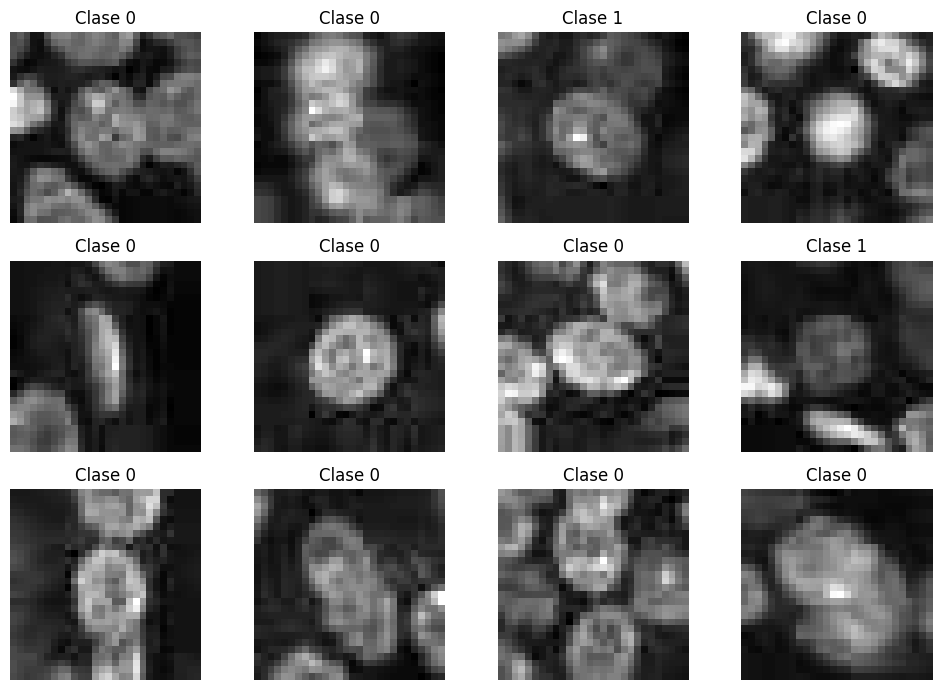

In [5]:
def show_batch(dataset, n=12):
    n = min(n, len(dataset))
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(10, 7))
    for i in range(n):
        x, y = dataset[i]
        img = x.squeeze().numpy()
        img = img * 0.5 + 0.5

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Clase {y}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_data, n=12)

## 4. DataLoaders

In [6]:
BATCH_SIZE = 128

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

x_batch, y_batch = next(iter(train_loader))
print("Forma de las imágenes:", x_batch.shape)
print("Forma de las etiquetas:", y_batch.shape)

Forma de las imágenes: torch.Size([128, 1, 28, 28])
Forma de las etiquetas: torch.Size([128])


## 5. CNN modificada: BatchNorm + Dropout + más filtros

In [7]:
class TissueCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.40),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TissueCNN(num_classes=2).to(device)
print(model)

TissueCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)


## 6. Funciones de entrenamiento y evaluación

In [9]:
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    total_loss = 0.0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs >= 0.5).long()

            total_loss += loss.item() * y.size(0)
            total += y.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    metrics = {
        "loss": total_loss / total,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

    return metrics, y_true, y_pred, y_prob


def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        total += y.size(0)

    return running_loss / total

## 7. Learning Rate y Scheduler

In [14]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

EPOCHS = 40

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_metrics, _, _, _ = evaluate(model, val_loader)

    scheduler.step(val_metrics["loss"])
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_auc"].append(val_metrics["roc_auc"])
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val AUC: {val_metrics['roc_auc']:.4f} | "
        f"LR: {current_lr:.6f}"
    )

Epoch 01/40 | Train Loss: 0.2942 | Val Loss: 0.3160 | Val Acc: 0.8801 | Val AUC: 0.7876 | LR: 0.001000
Epoch 02/40 | Train Loss: 0.2937 | Val Loss: 0.5402 | Val Acc: 0.7200 | Val AUC: 0.7549 | LR: 0.001000
Epoch 03/40 | Train Loss: 0.2941 | Val Loss: 0.3236 | Val Acc: 0.8788 | Val AUC: 0.7899 | LR: 0.001000
Epoch 04/40 | Train Loss: 0.2900 | Val Loss: 0.5049 | Val Acc: 0.7448 | Val AUC: 0.7712 | LR: 0.000500
Epoch 05/40 | Train Loss: 0.2812 | Val Loss: 0.3332 | Val Acc: 0.8772 | Val AUC: 0.7894 | LR: 0.000500
Epoch 06/40 | Train Loss: 0.2780 | Val Loss: 0.3746 | Val Acc: 0.8349 | Val AUC: 0.7862 | LR: 0.000500
Epoch 07/40 | Train Loss: 0.2752 | Val Loss: 0.3397 | Val Acc: 0.8799 | Val AUC: 0.7818 | LR: 0.000250
Epoch 08/40 | Train Loss: 0.2666 | Val Loss: 0.3691 | Val Acc: 0.8407 | Val AUC: 0.7832 | LR: 0.000250
Epoch 09/40 | Train Loss: 0.2637 | Val Loss: 0.3161 | Val Acc: 0.8803 | Val AUC: 0.7972 | LR: 0.000250
Epoch 10/40 | Train Loss: 0.2603 | Val Loss: 0.3252 | Val Acc: 0.8780 | V

## 8. Gráficas de entrenamiento

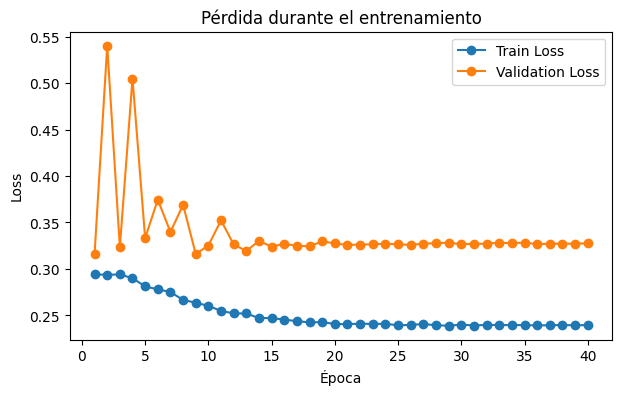

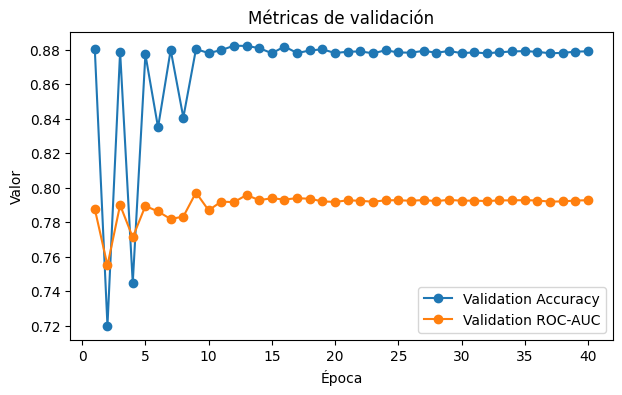

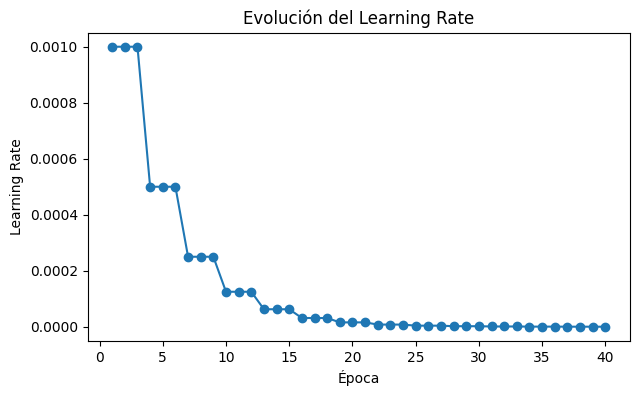

In [15]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.plot(epochs, history["val_auc"], marker="o", label="Validation ROC-AUC")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.title("Métricas de validación")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["lr"], marker="o")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.title("Evolución del Learning Rate")
plt.show()

## Análisis de las gráficas de entrenamiento

### Pérdida durante el entrenamiento

La gráfica muestra que la **pérdida de entrenamiento disminuye progresivamente** desde aproximadamente 0.30 hasta 0.24. Esto indica que el modelo va aprendiendo y ajustando sus parámetros durante las épocas.

Por otro lado, la **pérdida de validación presenta variaciones al inicio**, pero después se mantiene alrededor de 0.33. Esto indica que, a partir de cierto punto, el modelo deja de obtener mejoras importantes sobre los datos de validación.

### Métricas de validación

La **accuracy de validación** presenta algunas variaciones durante las primeras épocas y posteriormente se mantiene cercana a **0.88**. El **ROC-AUC** también mejora inicialmente y luego se estabiliza alrededor de **0.79**.

Esto permite observar que el modelo alcanza un comportamiento relativamente estable después de las primeras épocas.

### Evolución del Learning Rate

La tercera gráfica muestra cómo el **Learning Rate disminuye progresivamente** desde `0.001` hasta valores cercanos a cero. Esto ocurre debido al **Scheduler**, que reduce la tasa de aprendizaje cuando el rendimiento de validación deja de mejorar.

En general, las gráficas permiten observar el proceso de aprendizaje del modelo y cómo el uso del Scheduler ayuda a reducir gradualmente la velocidad de actualización de los parámetros.

## 9. Evaluación de la CNN

Resultados CNN:
loss: 0.3265
accuracy: 0.8768
precision: 0.5464
recall: 0.2373
f1: 0.3309
roc_auc: 0.7957


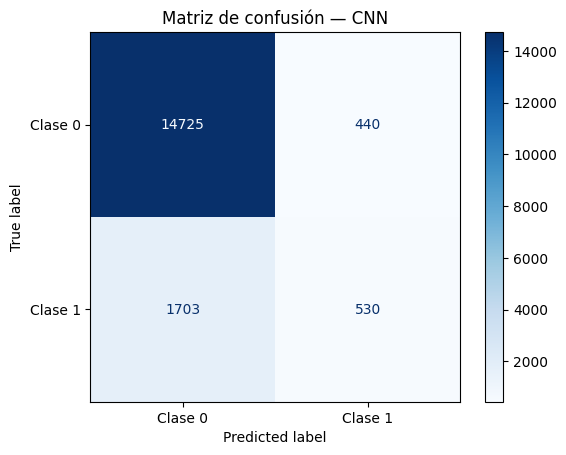

In [16]:
cnn_metrics, y_true_cnn, y_pred_cnn, y_prob_cnn = evaluate(model, test_loader)

print("Resultados CNN:")
for k, v in cnn_metrics.items():
    print(f"{k}: {v:.4f}")

cm = confusion_matrix(y_true_cnn, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Clase 0", "Clase 1"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión — CNN")
plt.show()

##Análisis de la evaluación de la CNN

La evaluación final de la CNN permitió analizar su comportamiento utilizando datos que no fueron empleados durante el entrenamiento. El modelo obtuvo una **accuracy de 87,68 %**, mientras que la precisión fue de **50,46 %**, el recall de **23,73 %**, el F1-score de **33,09 %** y el ROC-AUC de **79,57 %**.

La matriz de confusión muestra que el modelo clasificó correctamente **14 725 imágenes de la Clase 0** y **530 imágenes de la Clase 1**. Sin embargo, se observa que **1 703 imágenes de la Clase 1 fueron clasificadas como Clase 0**, lo que indica que al modelo le resulta más difícil reconocer correctamente esta clase.

En general, los resultados muestran que la CNN presenta un buen porcentaje de aciertos globales, pero todavía existen diferencias en el reconocimiento de ambas clases. Por ello, las métricas y la matriz de confusión permiten identificar aspectos que pueden mejorarse mediante técnicas como **Data Augmentation, ajuste de la arquitectura y Fine-Tuning**.

## 10. Data Augmentation

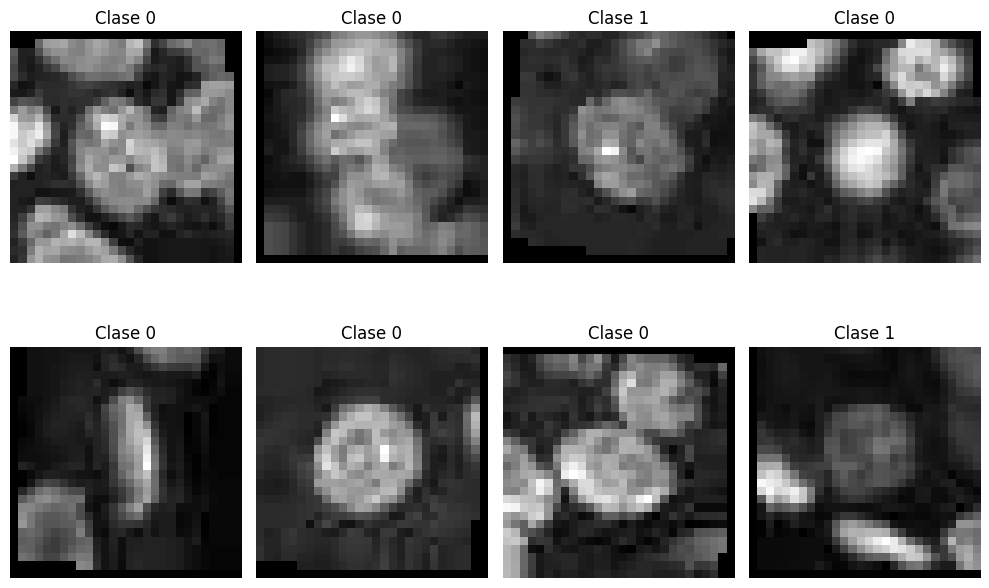

In [17]:
transform_aug = T.Compose([
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_aug_full = DataClass(split="train", transform=transform_aug, download=True)
train_aug_data = BinarySubset(train_aug_full, TARGET_CLASSES)

train_aug_loader = DataLoader(
    train_aug_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

show_batch(train_aug_data, n=8)

In [18]:
model_aug = TissueCNN(num_classes=2).to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)

history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(6):
    train_loss = train_one_epoch(model_aug, train_aug_loader, optimizer_aug)
    val_metrics, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_metrics["loss"])
    history_aug["val_acc"].append(val_metrics["accuracy"])
    history_aug["val_auc"].append(val_metrics["roc_auc"])

    print(
        f"Epoch {epoch+1:02d}/6 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val AUC: {val_metrics['roc_auc']:.4f}"
    )

aug_metrics, y_true_aug, y_pred_aug, y_prob_aug = evaluate(model_aug, test_loader)

print("\nResultados CNN + Data Augmentation:")
for k, v in aug_metrics.items():
    print(f"{k}: {v:.4f}")

Epoch 01/6 | Train Loss: 0.3738 | Val Acc: 0.8708 | Val AUC: 0.6636
Epoch 02/6 | Train Loss: 0.3599 | Val Acc: 0.8716 | Val AUC: 0.6994
Epoch 03/6 | Train Loss: 0.3537 | Val Acc: 0.8716 | Val AUC: 0.7124
Epoch 04/6 | Train Loss: 0.3498 | Val Acc: 0.8716 | Val AUC: 0.7251
Epoch 05/6 | Train Loss: 0.3438 | Val Acc: 0.8742 | Val AUC: 0.7375
Epoch 06/6 | Train Loss: 0.3416 | Val Acc: 0.8716 | Val AUC: 0.7259

Resultados CNN + Data Augmentation:
loss: 0.3620
accuracy: 0.8718
precision: 1.0000
recall: 0.0009
f1: 0.0018
roc_auc: 0.7270


## 11. Transfer Learning con ResNet18

In [21]:
transform_resnet = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_resnet_full = DataClass(split="train", transform=transform_resnet, download=True)
val_resnet_full   = DataClass(split="val", transform=transform_resnet, download=True)
test_resnet_full  = DataClass(split="test", transform=transform_resnet, download=True)

train_resnet = BinarySubset(train_resnet_full, TARGET_CLASSES)
val_resnet   = BinarySubset(val_resnet_full, TARGET_CLASSES)
test_resnet  = BinarySubset(test_resnet_full, TARGET_CLASSES)

train_resnet_loader = DataLoader(train_resnet, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_resnet_loader   = DataLoader(val_resnet, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_resnet_loader  = DataLoader(test_resnet, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights=weights)

for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=1e-3)

In [22]:
def train_model(model, loader, optimizer, criterion, epochs=3):
    hist = {"loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * y.size(0)
            total += y.size(0)

        train_loss = running_loss / total

        model.eval()
        ys, ps, probs = [], [], []
        val_loss_total = 0
        n = 0

        with torch.no_grad():
            for x, y in val_resnet_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                p = torch.softmax(logits, dim=1)[:,1]

                val_loss_total += loss.item() * y.size(0)
                n += y.size(0)
                ys.extend(y.cpu().numpy())
                ps.extend((p >= 0.5).long().cpu().numpy())
                probs.extend(p.cpu().numpy())

        val_loss = val_loss_total / n
        val_acc = accuracy_score(ys, ps)
        val_auc = roc_auc_score(ys, probs)

        hist["loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)
        hist["val_auc"].append(val_auc)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}"
        )

    return hist

hist_resnet = train_model(
    resnet,
    train_resnet_loader,
    optimizer_resnet,
    criterion_resnet,
    epochs=3
)

Epoch 01/3 | Loss: 0.3671 | Val Acc: 0.8719 | Val AUC: 0.6916
Epoch 02/3 | Loss: 0.3592 | Val Acc: 0.8723 | Val AUC: 0.6973
Epoch 03/3 | Loss: 0.3580 | Val Acc: 0.8687 | Val AUC: 0.7027


## 12. Fine-Tuning

In [23]:
# Descongelamos layer4 y la capa final para adaptar características
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=1e-4
)

hist_ft = train_model(
    resnet,
    train_resnet_loader,
    optimizer_ft,
    criterion_resnet,
    epochs=3
)

Epoch 01/3 | Loss: 0.3407 | Val Acc: 0.8772 | Val AUC: 0.7570
Epoch 02/3 | Loss: 0.2736 | Val Acc: 0.8657 | Val AUC: 0.7605
Epoch 03/3 | Loss: 0.1659 | Val Acc: 0.8657 | Val AUC: 0.7549


## 13. Evaluación de ResNet18

Resultados ResNet18 + Fine-Tuning:
accuracy: 0.8668
precision: 0.4633
recall: 0.2400
f1: 0.3162
roc_auc: 0.7724


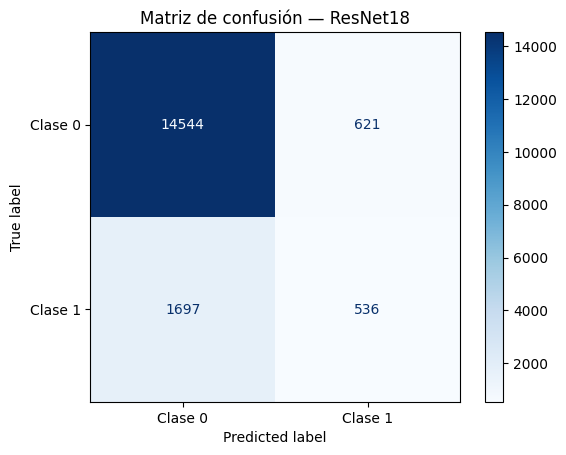

In [24]:
resnet.eval()
y_true_res, y_pred_res, y_prob_res = [], [], []

with torch.no_grad():
    for x, y in test_resnet_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet(x)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).long()

        y_true_res.extend(y.cpu().numpy())
        y_pred_res.extend(preds.cpu().numpy())
        y_prob_res.extend(probs.cpu().numpy())

y_true_res = np.array(y_true_res)
y_pred_res = np.array(y_pred_res)
y_prob_res = np.array(y_prob_res)

res_metrics = {
    "accuracy": accuracy_score(y_true_res, y_pred_res),
    "precision": precision_score(y_true_res, y_pred_res, zero_division=0),
    "recall": recall_score(y_true_res, y_pred_res, zero_division=0),
    "f1": f1_score(y_true_res, y_pred_res, zero_division=0),
    "roc_auc": roc_auc_score(y_true_res, y_prob_res)
}

print("Resultados ResNet18 + Fine-Tuning:")
for k, v in res_metrics.items():
    print(f"{k}: {v:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_true_res, y_pred_res,
    display_labels=["Clase 0", "Clase 1"],
    cmap="Blues"
)
plt.title("Matriz de confusión — ResNet18")
plt.show()

## Análisis de la evaluación de ResNet18 + Fine-Tuning

La evaluación de **ResNet18 con Fine-Tuning** permitió comparar su comportamiento utilizando el conjunto de prueba. El modelo obtuvo una **accuracy de 86,68 %**, un **precision de 46,33 %**, un **recall de 24,00 %**, un **F1-score de 31,62 %** y un **ROC-AUC de 77,24 %**.

La matriz de confusión muestra que se clasificaron correctamente **14 544 imágenes de la Clase 0** y **536 imágenes de la Clase 1**. Sin embargo, **1 697 imágenes de la Clase 1 fueron clasificadas como Clase 0**, lo que evidencia que el modelo todavía presenta dificultades para reconocer correctamente esta clase.

En comparación con la CNN, ResNet18 obtuvo resultados similares en accuracy, aunque las demás métricas muestran que el reconocimiento de la Clase 1 continúa siendo un aspecto por mejorar. Esto permite observar que el **Fine-Tuning** puede adaptar un modelo previamente entrenado al nuevo conjunto de datos, pero su desempeño depende de las características y distribución de las imágenes utilizadas.

## 14. Comparación global

In [25]:
comparison = {
    "CNN": cnn_metrics,
    "CNN + Augmentation": aug_metrics,
    "ResNet18 + Fine-Tuning": res_metrics
}

print(f"{'Modelo':<28} {'Accuracy':>10} {'ROC-AUC':>10} {'F1':>10}")
print("-" * 62)

for name, m in comparison.items():
    print(
        f"{name:<28} "
        f"{m['accuracy']:>10.4f} "
        f"{m['roc_auc']:>10.4f} "
        f"{m['f1']:>10.4f}"
    )

Modelo                         Accuracy    ROC-AUC         F1
--------------------------------------------------------------
CNN                              0.8768     0.7957     0.3309
CNN + Augmentation               0.8718     0.7270     0.0018
ResNet18 + Fine-Tuning           0.8668     0.7724     0.3162


## 15. Curvas ROC

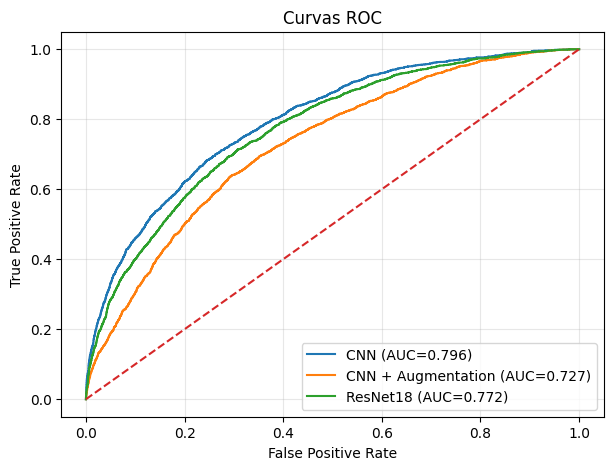

In [26]:
plt.figure(figsize=(7, 5))

for name, y_true, y_prob in [
    ("CNN", y_true_cnn, y_prob_cnn),
    ("CNN + Augmentation", y_true_aug, y_prob_aug),
    ("ResNet18", y_true_res, y_prob_res)
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Aálisis de las curvas ROC

En la gráfica se observa que los tres modelos presentan un comportamiento superior a la línea diagonal de referencia, lo que indica que tienen capacidad para distinguir entre las dos clases.

El modelo **CNN** obtuvo un **ROC-AUC de 0.796**, mientras que **ResNet18** alcanzó **0.772** y la **CNN con Data Augmentation** obtuvo **0.727**.

A partir de estos resultados, se puede observar que la CNN presenta la mayor capacidad de discriminación entre los modelos evaluados. Además, las curvas muestran cómo cambia la tasa de verdaderos positivos en relación con la tasa de falsos positivos a medida que se modifica el umbral.

En general, esta gráfica permite complementar las métricas anteriores y analizar el comportamiento de los modelos sin depender de un único umbral de clasificación.

## 16. Calibración de probabilidades

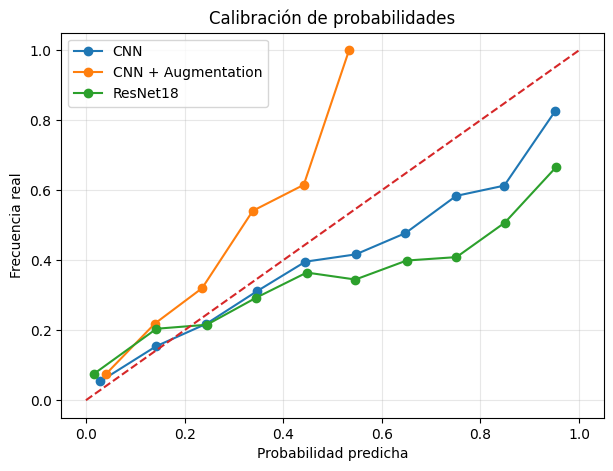

In [27]:
plt.figure(figsize=(7, 5))

for name, y_true, y_prob in [
    ("CNN", y_true_cnn, y_prob_cnn),
    ("CNN + Augmentation", y_true_aug, y_prob_aug),
    ("ResNet18", y_true_res, y_prob_res)
]:
    prob_true, prob_pred = calibration_curve(
        y_true, y_prob, n_bins=10, strategy="uniform"
    )
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia real")
plt.title("Calibración de probabilidades")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Análisis de calibración de probabilidades

La gráfica permite analizar qué tan cercanas están las **probabilidades predichas por los modelos** a la frecuencia real de las clases. La línea diagonal representa una calibración ideal, donde la probabilidad predicha coincide con la frecuencia observada.

Se observa que los tres modelos presentan diferencias respecto a esta línea. La **CNN** mantiene sus valores relativamente cercanos en varios intervalos, mientras que la **CNN con Data Augmentation** presenta algunas desviaciones más marcadas. **ResNet18** también muestra diferencias entre la probabilidad predicha y la frecuencia real.

En general, esta gráfica permite identificar que una predicción con una probabilidad alta no necesariamente significa que el modelo esté perfectamente calibrado. Por ello, además de evaluar la exactitud y el ROC-AUC, es importante analizar la **confiabilidad de las probabilidades** que entrega cada modelo.

## 17. Interpretabilidad básica: Grad-CAM

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


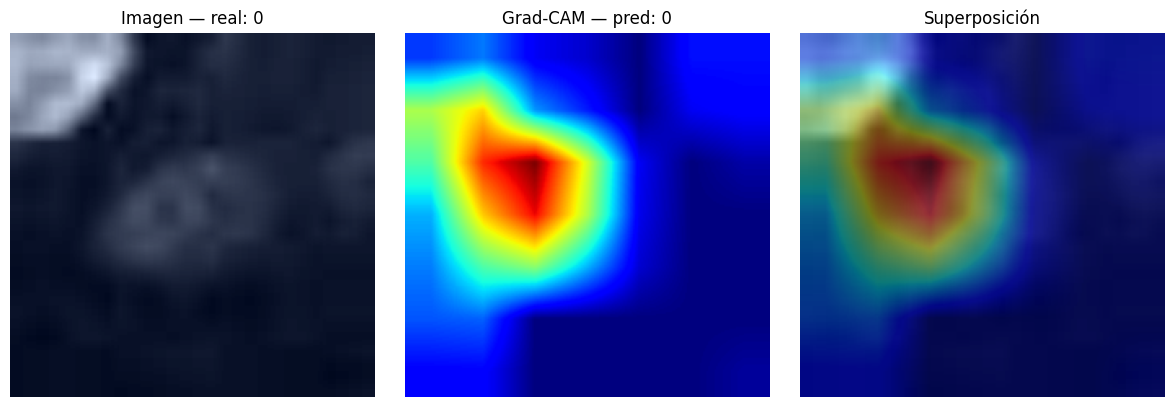

In [28]:
# Grad-CAM simplificado para ResNet18 sobre layer4

activations = {}
gradients = {}

def forward_hook(module, inp, out):
    activations["value"] = out

def backward_hook(module, grad_in, grad_out):
    gradients["value"] = grad_out[0]

handle_f = resnet.layer4.register_forward_hook(forward_hook)
handle_b = resnet.layer4.register_full_backward_hook(backward_hook)

def grad_cam(model, image, target_class=None):
    model.eval()
    model.zero_grad()

    x = image.unsqueeze(0).to(device)
    logits = model(x)

    if target_class is None:
        target_class = int(logits.argmax(dim=1).item())

    score = logits[0, target_class]
    score.backward()

    acts = activations["value"]
    grads = gradients["value"]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = torch.nn.functional.interpolate(
        cam, size=(image.shape[1], image.shape[2]),
        mode="bilinear", align_corners=False
    )

    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam, target_class

idx = 0
image, true_label = test_resnet[idx]
cam, pred_class = grad_cam(resnet, image)

img = image.permute(1,2,0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen — real: {true_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM — pred: {pred_class}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

handle_f.remove()
handle_b.remove()

## Análisis de interpretabilidad básica: Grad-CAM

La técnica **Grad-CAM** permitió visualizar qué regiones de la imagen tuvieron mayor influencia en la predicción realizada por la CNN. En la salida se muestran tres imágenes: la imagen original, el mapa de calor generado por Grad-CAM y la superposición de ambos.

En el mapa de calor, las zonas con mayor intensidad representan las regiones que tuvieron una mayor contribución a la predicción del modelo. En este caso, la mayor concentración de activación se encuentra alrededor de la estructura principal observada en la imagen.

Esto permite comprender mejor el comportamiento de la CNN, ya que no solo se obtiene la clase predicha, sino que también se puede observar **qué parte de la imagen fue relevante para tomar esa decisión**.

## 18. Guardado de modelos

In [29]:
torch.save(model.state_dict(), "tissuemnist_cnn.pth")
torch.save(model_aug.state_dict(), "tissuemnist_cnn_augmentation.pth")
torch.save(resnet.state_dict(), "tissuemnist_resnet18_finetuned.pth")

print("Modelos guardados correctamente.")

Modelos guardados correctamente.


## 19. Conclusiones

- Se logró adaptar el modelo trabajado en clase de **PneumoniaMNIST a TissueMNIST**, utilizando dos clases para realizar una clasificación binaria.

- Se comprendió la importancia de modificar la arquitectura de la **CNN** y probar técnicas como **BatchNorm, Dropout, Learning Rate y Scheduler**.

- El uso de **Data Augmentation** permitió analizar cómo las variaciones en las imágenes pueden ayudar a mejorar la capacidad de generalización del modelo.

- Con **Transfer Learning y Fine-Tuning mediante ResNet18**, se comprendió cómo aprovechar un modelo previamente entrenado para trabajar con un nuevo conjunto de imágenes.

- Finalmente, las métricas, curvas **ROC** y **Grad-CAM** permitieron evaluar e interpretar mejor el comportamiento de los modelos.